In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from gryffin import Gryffin
import olympus
from olympus import Surface

In [2]:
objective = Surface(kind='Dejong', param_dim=2)

def compute_objective(param):
    param['obj'] = objective.run([val for key, val in param.items()])[0][0]
    return param

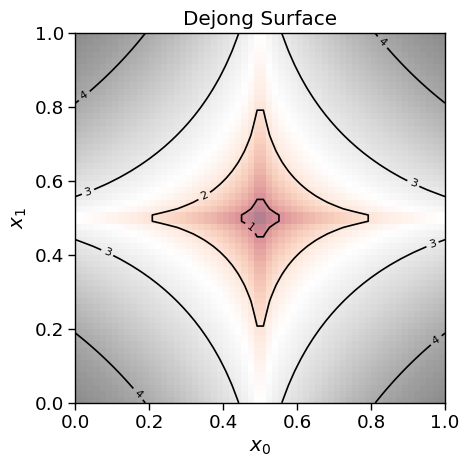

In [3]:

x_domain = np.linspace(0., 1., 60)
y_domain = np.linspace(0., 1., 60)
X, Y = np.meshgrid(x_domain, y_domain)
Z = np.zeros((x_domain.shape[0], y_domain.shape[0]))

for x_index, x_element in enumerate(x_domain):
    for y_index, y_element in enumerate(y_domain):
        loss_value = objective.run([x_element, y_element])[0][0]
        Z[y_index, x_index] = loss_value

fig, ax = plt.subplots()
contours = plt.contour(X, Y, Z, 3, colors='black')
ax.clabel(contours, inline=True, fontsize=8)
ax.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='RdGy', alpha=0.5)
_  = ax.set_title('Dejong Surface')
_ = ax.set_xlabel('$x_0$')
_ = ax.set_ylabel('$x_1$')

In [4]:
config = {
    "general": {
        "random_seed": 42,
        "verbosity": 0,
        "boosted":  False,
    },
    "parameters": [
        {"name": "x_0", "type": "continuous", "low": 0.0, "high": 1.0},
        {"name": "x_1", "type": "continuous", "low": 0.0, "high": 1.0},
    ],
    "objectives": [
        {"name": "obj", "goal": "min"},
    ]
}

In [5]:
def known_constraints(param):
    return param['x_0'] + param['x_1'] < 1.2

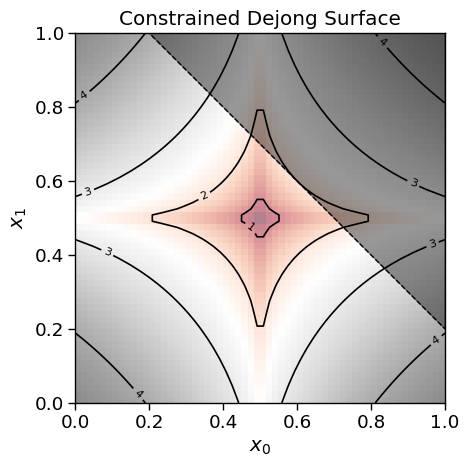

In [6]:
fig, ax = plt.subplots()
contours = plt.contour(X, Y, Z, 3, colors='black')
ax.clabel(contours, inline=True, fontsize=8)
ax.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='RdGy', alpha=0.5)

ax.plot(x_domain, 1.2-y_domain, c='k', ls='--', lw=1)
ax.fill_between(x_domain, 1.2-y_domain, 1.2-y_domain+0.8, color='k', alpha=0.4, )
ax.set_ylim(0., 1.)

_ = ax.set_title('Constrained Dejong Surface')
_ = ax.set_xlabel('$x_0$')
_ = ax.set_ylabel('$x_1$')

In [7]:
gryffin = Gryffin(config_dict=config, known_constraints=known_constraints)

In [9]:
sampling_strategies = [1, -1]

In [11]:
observations = []
MAX_ITER = 24

for num_iter in range(MAX_ITER):
    print('-'*20, 'Iteration:', num_iter+1, '-'*20)

    # Select alternating sampling strategy (i.e. lambda value presented in the Phoenics paper)
    select_ix = num_iter % len(sampling_strategies)
    sampling_strategy = sampling_strategies[select_ix]

    # Query for new parameters
    params  = gryffin.recommend(
        observations = observations,
        sampling_strategies=[sampling_strategy]
    )

    param = params[0]
    print('  Proposed Parameters:', param, end=' ')

    # Evaluate the proposed parameters.
    observation = compute_objective(param)
    print('==> Merit:', observation['obj'])

    # Append this observation to the previous experiments
    observations.append(param)

-------------------- Iteration: 1 --------------------
  Proposed Parameters: {'x_0': 0.19629431, 'x_1': 0.022564512} ==> Merit: 3.927745
-------------------- Iteration: 2 --------------------


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations